In [1]:
import glob
import pickle
import seaborn as sns
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
import tqdm
import pandas as pd

import numpy as np

from experiments.end_to_end.proof_node import ErrorNode
from experiments.end_to_end.proof_node import InternalNode

mini_f2f_traces = glob.glob('../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/*')



In [2]:
paths = {'p0.99_e0.1': glob.glob("../runs/minif2f/combined_model-p0.99-e0.1/2024_08_17/07_26_05/traces/0/*"),
         'p0.95_e0.1': glob.glob("../runs/minif2f/combined_model-p0.95-e0.1/2024_08_17/10_45_17/traces/0/*"),
         'p0.5_e0.1': glob.glob("../runs/minif2f/combined_model-p0.5-e0.1/2024_08_15/15_11_20/traces/0/*"),
         'p0.9_e0.5': glob.glob("../runs/minif2f/combined_model-p0.9-e0.5/2024_08_19/01_35_19/traces/0/*"),
         'p0.9_e0.1': glob.glob("../runs/minif2f/combined_model-p0.9-e0.1/2024_08_16/16_45_36/traces/0/*"),
         'p0.75_e0.5': glob.glob("../runs/minif2f/combined_model-p0.75-e0.5/2024_08_18/02_44_45/traces/0/*"),
         'p0.75_e0.1': glob.glob("../runs/minif2f/combined_model-p0.75-e0.1/2024_08_15/17_29_37/traces/0/*"),
         'bestfs': glob.glob("../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/*")
         }

In [3]:
def get_unique_children(node):
    # get valid tactics:
    valid_tactics = set()
    seen = set()
    for response in node.out_edges:
        result = response.dst

        for result_node in result:
            if isinstance(result_node,
                          InternalNode) and result_node not in seen:
                seen.add(result_node)
                tac = (response.tactic, response.tac_logprob)
                if tac not in valid_tactics:
                    valid_tactics.add(tac)

    num_valid = len([d.dst[0] for d in node.out_edges if
                     node.out_edges and not isinstance(d.dst[0], ErrorNode)])

    if num_valid > 0:
        return len(valid_tactics) / num_valid
    else:
        return None


def get_trace_stats(traces):
    lens = []
    valid_tactics = []
    total_edges = []
    unique = []

    tac_times = []
    env_times = []
    expansions = []
    num_nodes = []
    fully_expanded = []

    for file in tqdm.tqdm(traces):
        edge_count = []
        unique_ = []
        try:
            with open(file, 'rb') as f:
                trace = pickle.load(f)
        except:
            # print('error loading')
            continue
        if not trace:
            print('empty')
            continue

        if trace.proof:
            lens.append(len(trace.proof))

        num_edges = len(trace.trace)
        num_successes = 0

        for edge in trace.trace:
            if not isinstance(edge.dst[0], ErrorNode):
                num_successes += 1
        valid_tactics.append(num_successes / num_edges)

        for node in trace.nodes.values():
            if node.out_edges:
                edge_count.append(len(node.out_edges))

                uc = get_unique_children(node)
                if uc:
                    unique_.append(uc)

        if edge_count:
            total_edges.append(np.mean(edge_count))
        else:
            total_edges.append(0)

        unique.append(np.mean(unique_))

        tac_times.append(trace.tac_time)
        env_times.append(trace.env_time)
        expansions.append(trace.num_expansions)
        num_nodes.append(trace.num_nodes)
        fully_expanded.append(len([n for n in trace.nodes.values() if n.is_explored]))

    return {'proof_lens': lens, 'valid_tacs': valid_tactics, 'edge_count': total_edges, 'unique_children': unique,
            'tac_times': tac_times, 'env_times': env_times, 'expansions': expansions, 'num_nodes': num_nodes,
            'fully_expanded': fully_expanded}


# correlation between model logprob and error rate (e.g. logistic regression with logprob to predict error status)
def get_logprob_error_data(file):
    log_status_data = []
    for file in tqdm.tqdm(file):
        try:
            with open(file, 'rb') as f:
                trace = pickle.load(f)
        except:
            # print('error loading')
            continue
        if not trace:
            print('empty')
            continue

        for edge in trace.trace:
            if not isinstance(edge.dst[0], ErrorNode):
                success = 1
            else:
                success = 0
            log_status_data.append((edge.tac_logprob, success))

    return log_status_data

In [4]:
data = {}
for path in paths:
    data[path] = get_trace_stats(paths[path])


 95%|█████████▌| 233/244 [00:24<00:00, 12.70it/s]/home/sean/Documents/venvs/bait/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/sean/Documents/venvs/bait/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
100%|██████████| 244/244 [00:15<00:00, 15.28it/s]


In [5]:
logprob_data = get_logprob_error_data(mini_f2f_traces)

100%|██████████| 244/244 [00:18<00:00, 13.32it/s]


In [6]:
# get correlation between logprob and error status


df = pd.DataFrame(logprob_data, columns=['logprob', 'error'])

print(f'Correlation: \n{df.corr()}\n')

# try to predict error status from logprob with logistic regression

X = df['logprob'].values.reshape(-1, 1)
y = df['error'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

clf = LogisticRegression()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

# get f1 score, precision, recall, confusion matrix


print(f'F1: {f1_score(y_test, y_pred)}')
print(f'Precision: {precision_score(y_test, y_pred)}')
print(f'Recall: {recall_score(y_test, y_pred)}\n')

print(f'Confusion matrix: \n {confusion_matrix(y_test, y_pred, normalize="true")}')


# takeaway: logprob is not a good predictor of error status!

Correlation: 
          logprob     error
logprob  1.000000  0.090665
error    0.090665  1.000000

F1: 0.04920514761544285
Precision: 0.4416306361951822
Recall: 0.026054002842254856

Confusion matrix: 
 [[0.98748009 0.01251991]
 [0.973946   0.026054  ]]


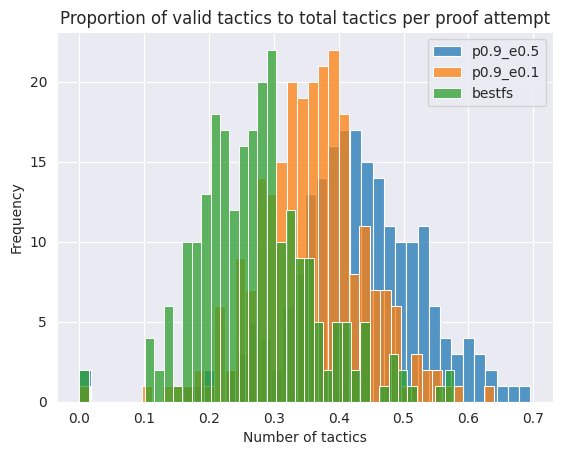

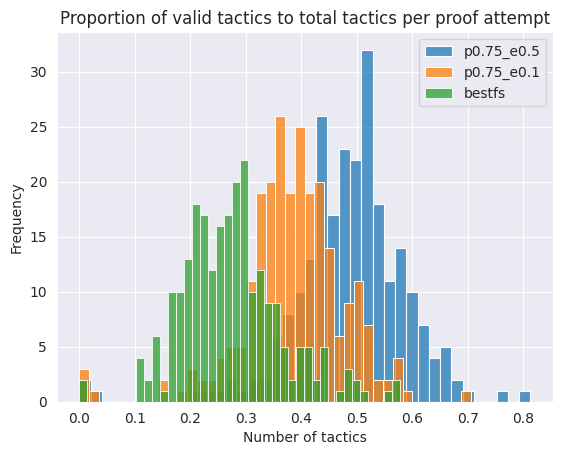

In [7]:
# overlay the two plots
# chosen_paths = ['p0.75_e0.5', 'p0.75_e0.1', 'bestfs']
chosen_paths = ['p0.9_e0.5', 'p0.9_e0.1', 'bestfs']
# chosen_paths = ['p0.9_e0.1', 'p0.5_e0.1', 'p0.95_e0.1', 'p0.75_e0.1', 'bestfs']
# chosen_paths = list(data.keys())

for p in chosen_paths:
    sns.histplot(data[p]['valid_tacs'], label=p, bins=40)

plt.legend()
plt.title('Proportion of valid tactics to total tactics per proof attempt')
plt.xlabel('Number of tactics')
plt.ylabel('Frequency')
plt.show()

chosen_paths = ['p0.75_e0.5', 'p0.75_e0.1', 'bestfs']
for p in chosen_paths:
    sns.histplot(data[p]['valid_tacs'], label=p, bins=40)

plt.legend()
plt.title('Proportion of valid tactics to total tactics per proof attempt')
plt.xlabel('Number of tactics')
plt.ylabel('Frequency')
plt.show()


# takeaway: higher e -> more valid tactics, higher p diminishes effect, since more of the ground set are forced to be chosen


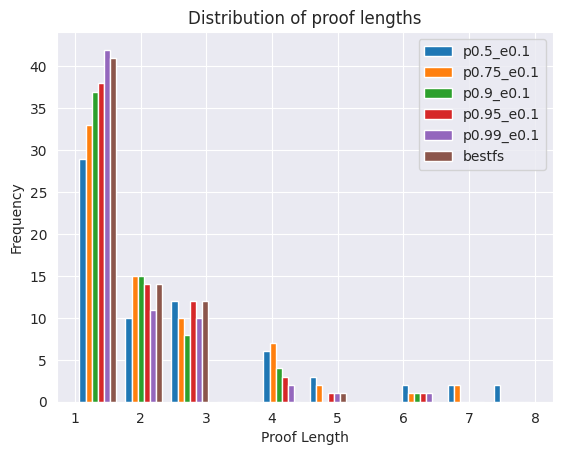

In [8]:
chosen_paths = ['p0.5_e0.1', 'p0.75_e0.1', 'p0.9_e0.1', 'p0.95_e0.1', 'p0.99_e0.1', 'bestfs']

plt.hist([data[p]['proof_lens'] for p in chosen_paths])
plt.legend(chosen_paths)

plt.title('Distribution of proof lengths')
plt.xlabel('Proof Length')
plt.ylabel('Frequency')

# plt.legend(['BestFS', 'e = 0.5', 'e = 0.1'])
plt.show()


#  higher p -> shorter proofs, higher e -> longer proofs
 # todo check like for like (overlapping proofs longer vs new proofs longer)

In [1]:
            # add title, labels, legend
# chosen_paths = ['p0.5_e0.1', 'p0.75_e0.1', 'p0.9_e0.1', 'p0.95_e0.1', 'bestfs']
# chosen_paths = ['p0.5_e0.1', 'p0.75_e0.5', 'p0.75_e0.1', 'p0.9_e0.1','p0.9_e0.5', 'p0.95_e0.1', 'p0.99_e0.1']
chosen_paths = ['p0.75_e0.5', 'p0.75_e0.1', 'p0.9_e0.1','p0.9_e0.5' ]

for p in chosen_paths:
    sns.histplot(data[p]['edge_count'], label=p, bins=40)
plt.legend()

# plt.hist([data[p]['edge_count'] for p in chosen_paths])
# plt.legend([k for k in data.keys()])


plt.title('Edge count')
plt.xlabel('Edge count')
plt.ylabel('Frequency')
plt.show()

# takeaway higher p -> more edges (unsurprising)


NameError: name 'sns' is not defined

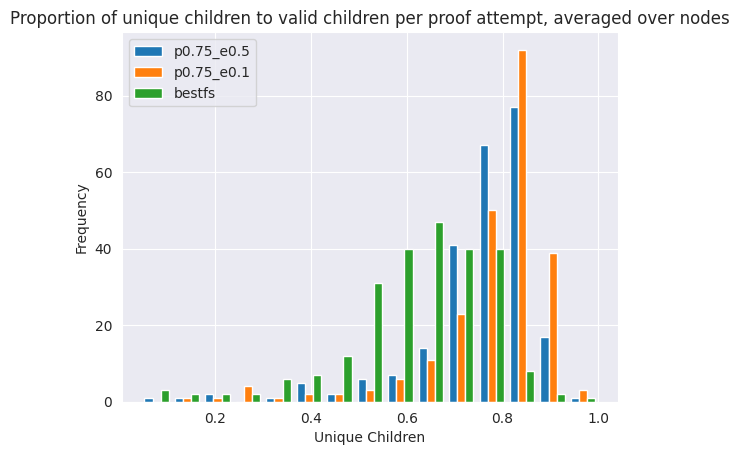

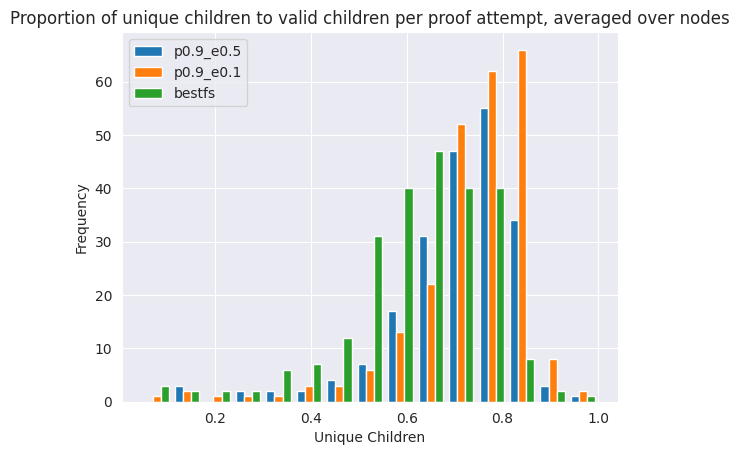

In [10]:
chosen_paths = ['p0.75_e0.5', 'p0.75_e0.1', 'bestfs']

# for p in chosen_paths:
#     sns.histplot(data[p]['unique_children'], label=p, bins=40)
# plt.legend()

plt.hist([data[p]['unique_children'] for p in chosen_paths], bins=15)
plt.legend(chosen_paths)
plt.title('Proportion of unique children to valid children per proof attempt, averaged over nodes')
plt.xlabel('Unique Children')
plt.ylabel('Frequency')
plt.show()

chosen_paths = ['p0.9_e0.5', 'p0.9_e0.1', 'bestfs']
plt.hist([data[p]['unique_children'] for p in chosen_paths], bins=15)
plt.legend(chosen_paths)
plt.title('Proportion of unique children to valid children per proof attempt, averaged over nodes')
plt.xlabel('Unique Children')
plt.ylabel('Frequency')
plt.show()


# takeaway: e = 0.1 has the highest proportion of unique children, followed by e=0.5, and bestfs
# suggests that diversity is favored more for e=0.1 vs e=0.5, when controlling for number of successful tactics


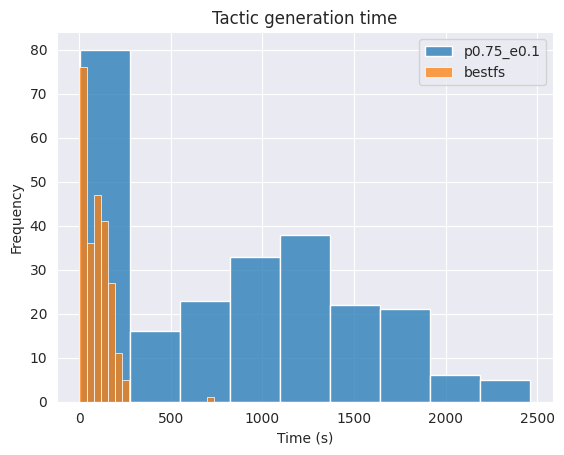

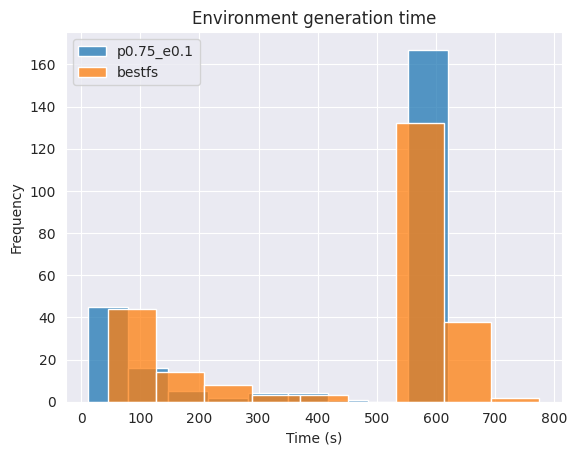

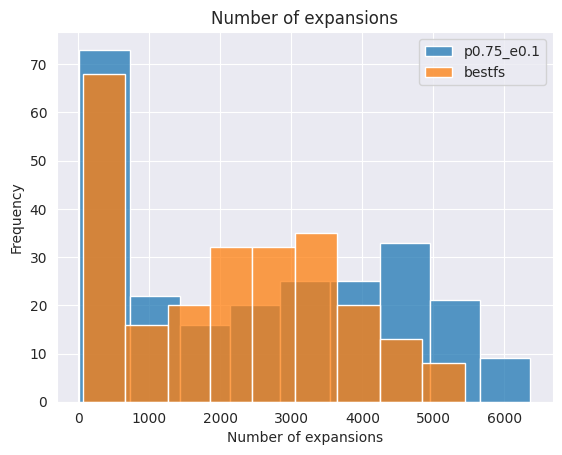

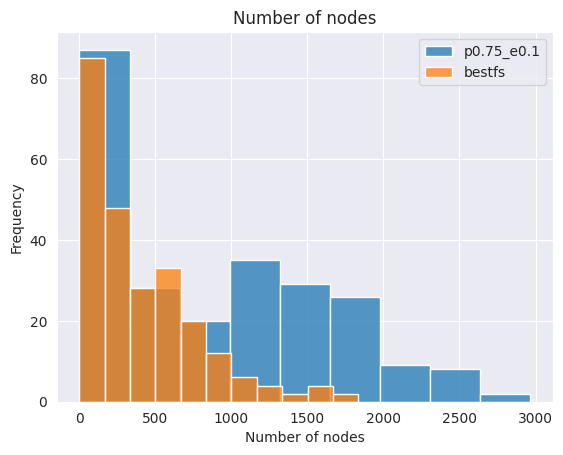

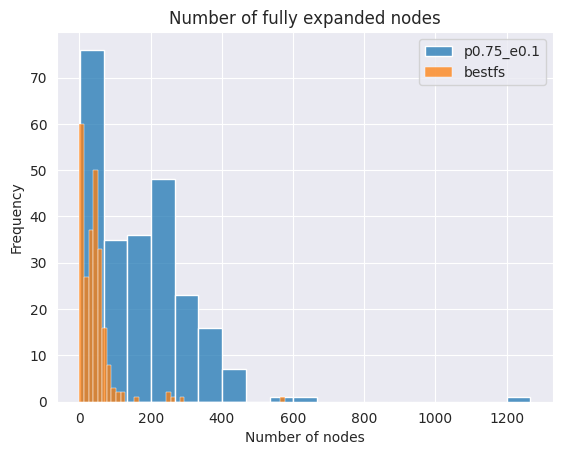

In [11]:
# histogram of all statistics above:

chosen_paths = ['p0.75_e0.1', 'bestfs']

for p in chosen_paths:
    sns.histplot(data[p]['tac_times'], label=p)

plt.title('Tactic generation time')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

for p in chosen_paths:
    sns.histplot(data[p]['env_times'], label=p)  #, bins=40)

plt.title('Environment generation time')
plt.xlabel('Time (s)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

for p in chosen_paths:
    sns.histplot(data[p]['expansions'], label=p)  #, bins=40)

plt.title('Number of expansions')
plt.xlabel('Number of expansions')
plt.ylabel('Frequency')
plt.legend()
plt.show()

for p in chosen_paths:
    sns.histplot(data[p]['num_nodes'], label=p)  #, bins=40)

plt.title('Number of nodes')
plt.xlabel('Number of nodes')
plt.ylabel('Frequency')
plt.legend()
plt.show()

for p in chosen_paths:
    sns.histplot(data[p]['fully_expanded'], label=p)  #, bins=40)

plt.title('Number of fully expanded nodes')
plt.xlabel('Number of nodes')
plt.ylabel('Frequency')
plt.legend()
plt.show()


In [22]:
# compare traces from p0.75_e0.1 and bestfs, noting if expansions is greater in p0.75_e0.1 and if it has a proof and bestfs does not:

p075_e01 = glob.glob("../runs/minif2f/combined_model-p0.75-e0.1/2024_08_15/17_29_37/traces/0/*")
bestfs = glob.glob("../runs/minif2f/minif2f_bestfs/2024_07_31/16_28_47/traces/0/*")

for p, b in tqdm.tqdm(zip(p075_e01, bestfs)):
    with open(p, 'rb') as f:
        trace_p = pickle.load(f)
    with open(b, 'rb') as f:
        trace_b = pickle.load(f)

    if trace_p.num_expansions > trace_b.num_expansions and trace_p.proof and not trace_b.proof:
        print('p075_e01 has more expansions and a proof, bestfs does not')

                                

244it [00:54,  4.51it/s]


In [12]:

# 
# # aggregated per trace
# def successful_tacs_total(file):
#     valid_tactics = []
#     for file in tqdm.tqdm(file):
#         try:
#             with open(file, 'rb') as f:
#                 trace = pickle.load(f)
#         except:
#             print('error loading')
#             continue
#         if not trace:
#             print('empty')
#             continue
# 
#         num_edges = len(trace.trace)
#         num_successes = 0
# 
#         for edge in trace.trace:
#             if not isinstance(edge.dst[0], ErrorNode):
#                 num_successes += 1
#         valid_tactics.append(num_successes / num_edges)
# 
#     return valid_tactics
# 

# def get_valid_tactics(node):
#     return len([d.dst[0] for d in node.out_edges if
#                 node.out_edges and not isinstance(d.dst[0], ErrorNode)]) / len(node.out_edges)
#    # node.out_edges and not isinstance(d.dst[0], ErrorNode) and not isinstance(d.dst[0], ProofFinishedNode)]) / len(node.out_edges)
# per node 

# def successful_tacs(file):
#     valid_tactics = []
#     for file in tqdm.tqdm(file):
#         try:
#             with open(file, 'rb') as f:
#                 trace = pickle.load(f)
#         except:
#             print('error loading')
#             continue
#         if not trace:
#             print('empty')
#             continue
#         for node in trace.nodes.values():
#             if node.out_edges:
#                 valid_tactics.append(get_valid_tactics(node))
# 
#     return valid_tactics


# def out_edge_count(file):
#     total_edges = []
#     for file in tqdm.tqdm(file):
#         edge_count = []
#         try:
#             with open(file, 'rb') as f:
#                 trace = pickle.load(f)
#         except:
#             print('error loading')
#             continue
#         if not trace:
#             print('empty')
#             continue
# 
#         for node in trace.nodes.values():
#             if node.out_edges:
#                 edge_count.append(len(node.out_edges))
# 
#         if edge_count:
#             total_edges.append(np.mean(edge_count))
#         else:
#             total_edges.append(0)
# 
#     return total_edges
# 
# 
# def unique_children(file):
#     unique = []
#     for file in tqdm.tqdm(file):
#         unique_ = []
#         try:
#             with open(file, 'rb') as f:
#                 trace = pickle.load(f)
#         except:
#             print('error loading')
#             continue
#         if not trace:
#             print('empty')
#             continue
# 
#         for node in trace.nodes.values():
#             if node.out_edges:
#                 uc = get_unique_children(node)
#                 if uc:
#                     unique_.append(uc)
# 
#         unique.append(np.mean(unique_))
# 
#     return unique
# 
# 
# def get_proof_lens(file):
#     lens = []
#     for file in tqdm.tqdm(file):
#         try:
#             with open(file, 'rb') as f:
#                 trace = pickle.load(f)
#         except:
#             print('error loading')
#             continue
#         if not trace:
#             print('empty')
#             continue
#         if trace.proof:
#             lens.append(len(trace.proof))
# 
#     return lens
# 

# plot the distribution of valid tactics (no direct error)

# valid_tacs = successful_tacs_total(mini_f2f_traces)
# valid_tacs_e5 = successful_tacs_total(p_75_e5)
# valid_tacs_e1 = successful_tacs_total(p_75_e1)
# valid_tacs_p90_e5 = successful_tacs_total(p_90_e5)
# valid_tacs_p50_e1 = successful_tacs_total(p_50_e1)
# valid_tacs_p90_e1 = successful_tacs_total(p90_e1)
# valid_tacs_p99_e1 = successful_tacs_total(p99_e1)
# valid_tacs_p95_e1 = successful_tacs_total(p95_e1)


# proof_lens_bestfs = get_proof_lens(mini_f2f_traces)
# proof_lens_e5 = get_proof_lens(p_75_e5)
# proof_lens_e1 = get_proof_lens(p_75_e1)
# unique_bestfs = unique_children(mini_f2f_traces)
# unique_e5 = unique_children(p_75_e5)
# unique_e1 = unique_children(p_75_e1)

# edge_count_e5 = out_edge_count(p_75_e5)
# edge_count_e1 = out_edge_count(p_75_e1)

# edge_count_p50_e1 = out_edge_count(p_50_e1)
# edge_count_p90_e5 = out_edge_count(p_90_e5)

# p_75_e5 = glob.glob("../runs/minif2f/combined_model-p0.75-e0.5/2024_08_18/02_44_45/traces/0/*")
# p_75_e1 = glob.glob("../runs/minif2f/combined_model-p0.75-e0.1/2024_08_15/17_29_37/traces/0/*")

# p_50_e1 = glob.glob("../runs/minif2f/combined_model-p0.5-e0.1/2024_08_15/15_11_20/traces/0/*")
# p_90_e5 = glob.glob("../runs/minif2f/combined_model-p0.9-e0.5/2024_08_19/01_35_19/traces/0/*")


# p90_e1 = glob.glob("../runs/minif2f/combined_model-p0.9-e0.1/2024_08_16/16_45_36/traces/0/", )
# p99_e1 = glob.glob("../runs/minif2f/combined_model-p0.99-e0.1/2024_08_17/07_26_05/traces/0/", )
# p95_e1 = glob.glob("../runs/minif2f/combined_model-p0.95-e0.1/2024_08_17/10_45_17/traces/0/", )



